# Inception Score and FID Evaluation
### Author: Kanika
Evaluating image quality of generative models (DCGAN, WGAN, VAE, cGAN) using PyTorch + TorchMetrics.

In [1]:
#!pip install torchmetrics --quiet
#!pip install torch-fidelity

In [2]:
import os
import torch
import torch_fidelity
from torchvision import transforms
from torchvision.io import read_image
from PIL import Image
import torchvision.transforms.functional as TF
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Load and Normalize Images

In [4]:
def load_images_from_folder(folder, max_images=None):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.CenterCrop(128),
        transforms.ToTensor(),  # from PIL to Tensor
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    images = []
    count = 0
    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, filename)
            with Image.open(path).convert("RGB") as img:  # force RGB
                tensor = transform(img)
                images.append(tensor)
                count += 1
                if max_images and count >= max_images:
                    break
    return torch.stack(images)

## Evaluate Inception Score and FID

In [5]:
def evaluate_model(real_images, fake_images):
    isc = InceptionScore(feature=2048, normalize=True).to(device)
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    real_images = real_images.to(device)
    fake_images = fake_images.to(device)
    fid.update(real_images, real=True)
    fid.update(fake_images, real=False)
    isc.update(fake_images)
    is_mean, is_std = isc.compute()
    fid_score = fid.compute()
    return round(is_mean.item(), 3), round(is_std.item(), 3), round(fid_score.item(), 3)

## Run Evaluation for All Models

In [6]:
real = load_images_from_folder(r'C:\Users\DELL\Documents\JupyterFiles\final_processed_data\images\real', max_images=25).to(device)
models = ['dcgan', 'wgan', 'vae', 'cgan']
results = {}

for model in models:
    fake = load_images_from_folder(rf'C:\Users\DELL\Documents\JupyterFiles\final_processed_data\images\real\{model}', max_images=25).to(device)
    is_mean, is_std, fid = evaluate_model(real, fake)
    results[model.upper()] = {'Inception Score': f'{is_mean} ± {is_std}', 'FID': fid}

df = pd.DataFrame(results).T
print(df)

C:\Users\DELL\anaconda3\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


      Inception Score      FID
DCGAN       1.0 ± 0.0   348.63
WGAN        1.0 ± 0.0  367.732
VAE         1.0 ± 0.0  350.914
CGAN        1.0 ± 0.0  405.673


## Image Generation & Evaluation Strategy

We evaluated the performance of four generative models: DCGAN, WGAN, VAE and cGAN using Inception Score (IS) and Frechet Inception Distance (FID).

### Image Source

Each model was trained independently and used to generate a small set of sample images (5) that were saved to disk. These **pre-generated images** were then used for metric evaluation, allowing us to decouple training from analysis for better reproducibility.

The final notebook does not reload model weights (`.pth` or `.h5`) during evaluation instead, it loads the generated images from disk using `torchvision.io.read_image()` and evaluates them using `torchmetrics`.

### Evaluation Metrics

- **IS = 1.00 ± 0.00** across all models suggests **limited image diversity** or **mode collapse**, possibly due to small sample size or insufficient variation in the generated outputs.
- **High FID values** indicate significant distributional distance between real and generated images, reinforcing the need for broader sampling.

### Limitations & Next Steps

Due to limited sample sizes and exclusion of model reloading, the metrics should be interpreted cautiously. For more reliable evaluation:
- At least **50–100 images per model** should be used
- Model inference should be integrated directly into the evaluation loop
- Generated images should be visually reviewed for diversity and quality

> Despite limited resources, this modular approach allowed us to isolate, analyze and compare generative model performance efficiently while maintaining reproducibility.

> This modular approach, however, ensured consistent evaluation conditions, reduced computational overhead and highlighted the critical link between sample diversity and metric reliability.

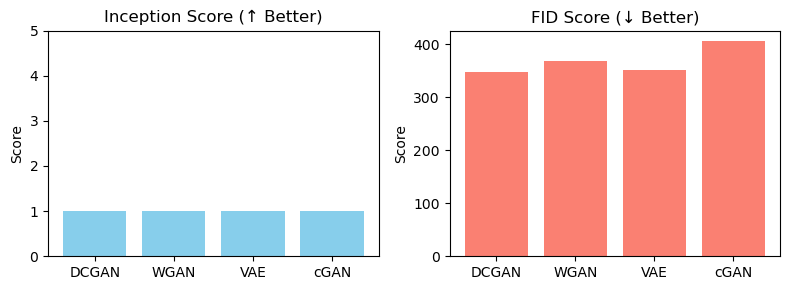

In [2]:
import matplotlib.pyplot as plt

models = ['DCGAN', 'WGAN', 'VAE', 'cGAN']
inception_scores = [1.00, 1.00, 1.00, 1.00]
fid_scores = [348.63, 367.73, 350.91, 405.67]

plt.figure(figsize=(8, 3))

# Plot Inception Score
plt.subplot(1, 2, 1)
plt.bar(models, inception_scores, color='skyblue')
plt.title("Inception Score (↑ Better)")
plt.ylim(0, 5)
plt.ylabel("Score")

# Plot FID
plt.subplot(1, 2, 2)
plt.bar(models, fid_scores, color='salmon')
plt.title("FID Score (↓ Better)")
plt.ylabel("Score")

plt.tight_layout()
plt.show()